# ↔️ Modèle BiLSTM — Détection de Commentaires Toxiques
**Dataset :** Jigsaw Toxic Comment Classification  
**Architecture :** BiLSTM (Bidirectional LSTM) + Attention  
> Assure-toi que le Runtime est configuré sur **GPU (T4)** : Runtime → Change runtime type → T4 GPU

## 1. 📦 Imports

In [2]:
import os, re, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Embedding, Bidirectional, LSTM, Dense,
    Dropout, SpatialDropout1D, GlobalMaxPooling1D,
    GlobalAveragePooling1D, Concatenate, Layer
)
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, f1_score, confusion_matrix

print(f'TensorFlow version : {tf.__version__}')
print(f'GPU disponible     : {tf.config.list_physical_devices("GPU")}')

TensorFlow version : 2.19.0
GPU disponible     : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2. 🔗 Connexion Drive & Chargement

In [3]:
from google.colab import drive
drive.mount('/content/drive')

# ─── CHEMIN de ma structure Drive ───────────────────────────────
DATA_DIR = '/content/drive/MyDrive/toxic_comment_project/data'
# ──────────────────────────────────────────────────────────────────────────────

train_df = pd.read_csv(os.path.join(DATA_DIR, 'train.csv'))
test_df  = pd.read_csv(os.path.join(DATA_DIR, 'test.csv'))

print(f'Train shape : {train_df.shape}')
print(f'Test  shape : {test_df.shape}')
train_df.head(3)

Mounted at /content/drive
Train shape : (159571, 8)
Test  shape : (153164, 2)


,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0


## 3. 🧹 Preprocessing

In [4]:
LABELS = ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']

# ─── Hyperparamètres ──────────────────────────────────────────────────────────
MAX_FEATURES  = 30000
MAX_LEN       = 200
EMBED_DIM     = 128
LSTM_UNITS    = 64
DROPOUT_RATE  = 0.3
BATCH_SIZE    = 256
EPOCHS        = 10
VAL_SPLIT     = 0.1
# ──────────────────────────────────────────────────────────────────────────────

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'https?://\S+|www\.\S+', ' url ', text)
    text = re.sub(r'[^a-z0-9\s!?.,]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

print('Nettoyage du texte...')
train_df['clean_text'] = train_df['comment_text'].apply(clean_text)
test_df['clean_text']  = test_df['comment_text'].apply(clean_text)

print('Tokenisation...')
tokenizer = Tokenizer(num_words=MAX_FEATURES, oov_token='<OOV>')
tokenizer.fit_on_texts(train_df['clean_text'])

X_train_seq = tokenizer.texts_to_sequences(train_df['clean_text'])
X_test_seq  = tokenizer.texts_to_sequences(test_df['clean_text'])

X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding='post', truncating='post')
X_test_pad  = pad_sequences(X_test_seq,  maxlen=MAX_LEN, padding='post', truncating='post')

y = train_df[LABELS].values
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_pad, y, test_size=VAL_SPLIT, random_state=42, stratify=y[:, 0]
)

print(f'X_train : {X_tr.shape} | X_val : {X_val.shape}')

Nettoyage du texte...
Tokenisation...
X_train : (143613, 200) | X_val : (15958, 200)


## 4. 🏗️ Architecture BiLSTM avec Attention

In [5]:
class AttentionLayer(Layer):
    """Couche d'attention simple pour pondérer les timesteps LSTM."""

    def __init__(self, **kwargs):
        super().__init__(**kwargs)

    def build(self, input_shape):
        self.W = self.add_weight(
            name='attention_weight',
            shape=(input_shape[-1], 1),
            initializer='glorot_uniform', trainable=True
        )
        self.b = self.add_weight(
            name='attention_bias',
            shape=(input_shape[1], 1),
            initializer='zeros', trainable=True
        )
        super().build(input_shape)

    def call(self, x):
        # Score d'attention par timestep
        e = tf.nn.tanh(tf.tensordot(x, self.W, axes=1) + self.b)
        a = tf.nn.softmax(e, axis=1)
        # Somme pondérée
        output = tf.reduce_sum(x * a, axis=1)
        return output


def build_bilstm_model(vocab_size, embed_dim, max_len, lstm_units, dropout_rate, n_labels=6):
    """BiLSTM avec attention + pooling mixte (max + mean + attention)."""
    inputs = Input(shape=(max_len,), name='input')

    # Embedding
    x = Embedding(vocab_size, embed_dim, input_length=max_len, name='embedding')(inputs)
    x = SpatialDropout1D(dropout_rate)(x)

    # BiLSTM 1 (retourne toutes les séquences)
    x = Bidirectional(
        LSTM(lstm_units, return_sequences=True, dropout=0.1, recurrent_dropout=0.1),
        name='bilstm_1'
    )(x)
    x = Dropout(dropout_rate)(x)

    # BiLSTM 2 (retourne toutes les séquences pour attention)
    x = Bidirectional(
        LSTM(lstm_units // 2, return_sequences=True, dropout=0.1, recurrent_dropout=0.1),
        name='bilstm_2'
    )(x)

    # Pooling triple : max + mean + attention → richer representation
    max_pool  = GlobalMaxPooling1D(name='global_max')(x)
    avg_pool  = GlobalAveragePooling1D(name='global_avg')(x)
    att_pool  = AttentionLayer(name='attention')(x)

    # Concaténation
    merged = Concatenate(name='concat')([max_pool, avg_pool, att_pool])
    merged = Dropout(dropout_rate)(merged)

    # Classifieur
    out = Dense(128, activation='relu', name='dense_1')(merged)
    out = Dropout(0.2)(out)
    out = Dense(64, activation='relu', name='dense_2')(out)
    out = Dense(n_labels, activation='sigmoid', name='output')(out)

    model = Model(inputs=inputs, outputs=out, name='BiLSTM_Attention_ToxicDetector')
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.AUC(name='auc', multi_label=True)]
    )
    return model


model_bilstm = build_bilstm_model(
    vocab_size=MAX_FEATURES + 1,
    embed_dim=EMBED_DIM,
    max_len=MAX_LEN,
    lstm_units=LSTM_UNITS,
    dropout_rate=DROPOUT_RATE
)
model_bilstm.summary()

Model: "BiLSTM_Attention_ToxicDetector"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 200)       │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 200, 128)  │  3,840,128 │ input[0][0]       │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout1d   │ (None, 200, 128)  │          0 │ embedding[0][0]   │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bilstm_1            │ (None, 200, 128)  │     98,816 │ spatial_dropout1… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 200, 128)  │          0 │ bilstm_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bilstm_2            │ (None, 200, 64)   │     41,216 │ dropout[0][0]     │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max          │ (None, 64)        │          0 │ bilstm_2[0][0]    │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_avg          │ (None, 64)        │          0 │ bilstm_2[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention           │ (None, 64)        │        264 │ bilstm_2[0][0]    │
│ (AttentionLayer)    │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concat              │ (None, 192)       │          0 │ global_max[0][0], │
│ (Concatenate)       │                   │            │ global_avg[0][0], │
│                     │                   │            │ attention[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 192)       │          0 │ concat[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 128)       │     24,704 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 128)       │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 64)        │      8,256 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 6)         │        390 │ dense_2[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 4,013,774 (15.31 MB)

 Trainable params: 4,013,774 (15.31 MB)

 Non-trainable params: 0 (0.00 B)

## 5. 🏋️ Entraînement

In [6]:
callbacks = [
    EarlyStopping(monitor='val_auc', patience=3, mode='max',
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_auc', factor=0.5, patience=2,
                     mode='max', min_lr=1e-5, verbose=1),
    ModelCheckpoint('/content/drive/MyDrive/toxic_comment_project/results/best_bilstm.keras',
                    monitor='val_auc', mode='max', save_best_only=True, verbose=1)
]

t0 = time.time()
history_bilstm = model_bilstm.fit(
    X_tr, y_tr,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    verbose=1
)
train_time_bilstm = time.time() - t0
print(f'\nTemps entraînement : {train_time_bilstm/60:.1f} min')

Epoch 1/10
561/561 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.7976 - auc: 0.6452 - loss: 0.1655
Epoch 1: val_auc improved from None to 0.96558, saving model to /content/drive/MyDrive/toxic_comment_project/results/best_bilstm.keras

Epoch 1: finished saving model to /content/drive/MyDrive/toxic_comment_project/results/best_bilstm.keras
561/561 ━━━━━━━━━━━━━━━━━━━━ 1548s 3s/step - accuracy: 0.9199 - auc: 0.8374 - loss: 0.1022 - val_accuracy: 0.9954 - val_auc: 0.9656 - val_loss: 0.0487 - learning_rate: 0.0010
Epoch 2/10
561/561 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9921 - auc: 0.9634 - loss: 0.0477
Epoch 2: val_auc improved from 0.96558 to 0.96771, saving model to /content/drive/MyDrive/toxic_comment_project/results/best_bilstm.keras

Epoch 2: finished saving model to /content/drive/MyDrive/toxic_comment_project/results/best_bilstm.keras
561/561 ━━━━━━━━━━━━━━━━━━━━ 1483s 3s/step - accuracy: 0.9908 - auc: 0.9640 - loss: 0.0476 - val_accuracy: 0.9954 - val_auc: 0.9677 - val_loss

## 6. 📈 Courbes d'apprentissage

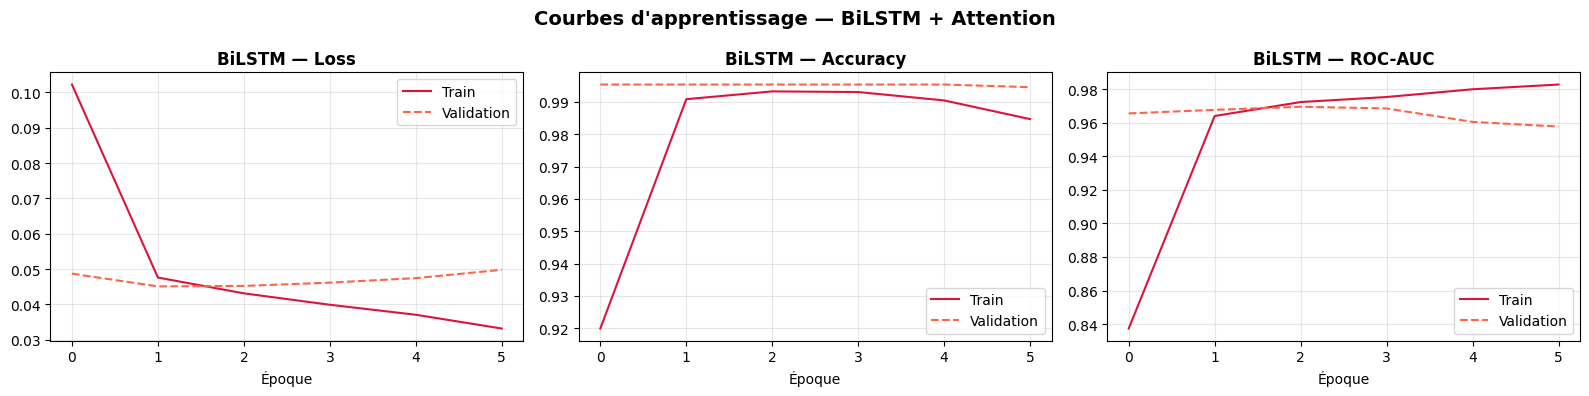

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
hist = history_bilstm.history
metrics_plot = [('loss', 'Loss'), ('accuracy', 'Accuracy'), ('auc', 'ROC-AUC')]

for ax, (m, title) in zip(axes, metrics_plot):
    ax.plot(hist[m], label='Train', color='crimson')
    ax.plot(hist[f'val_{m}'], label='Validation', color='tomato', linestyle='--')
    ax.set_title(f'BiLSTM — {title}', fontweight='bold')
    ax.set_xlabel('Époque')
    ax.legend()
    ax.grid(alpha=0.3)

plt.suptitle('Courbes d\'apprentissage — BiLSTM + Attention', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/toxic_comment_project/results/bilstm_history.png', dpi=150)
plt.show()

## 7. 📊 Évaluation

In [8]:
def evaluate_model(model, X_val, y_val, model_name='Modèle', threshold=0.5):
    y_proba = model.predict(X_val, batch_size=512, verbose=0)
    y_pred  = (y_proba >= threshold).astype(int)

    roc_macro = roc_auc_score(y_val, y_proba, average='macro')
    f1_macro  = f1_score(y_val, y_pred, average='macro',    zero_division=0)
    f1_micro  = f1_score(y_val, y_pred, average='micro',    zero_division=0)
    f1_weight = f1_score(y_val, y_pred, average='weighted', zero_division=0)

    print(f'\n{"═"*50}\n  {model_name}\n{"═"*50}')
    print(f'  ROC-AUC macro : {roc_macro:.4f}')
    print(f'  F1 macro      : {f1_macro:.4f}')
    print(f'  F1 micro      : {f1_micro:.4f}')
    print(f'  F1 weighted   : {f1_weight:.4f}\n')

    auc_per_label = {}
    for i, label in enumerate(LABELS):
        auc_l = roc_auc_score(y_val[:, i], y_proba[:, i])
        auc_per_label[label] = auc_l
        print(f'    {label:20s} → AUC = {auc_l:.4f}')

    return {
        'roc_auc_macro': roc_macro, 'f1_macro': f1_macro,
        'f1_micro': f1_micro, 'f1_weighted': f1_weight,
        'auc_per_label': auc_per_label,
        'y_proba': y_proba, 'y_pred': y_pred
    }

results_bilstm = evaluate_model(model_bilstm, X_val, y_val, 'BiLSTM + Attention')


══════════════════════════════════════════════════
  BiLSTM + Attention
══════════════════════════════════════════════════
  ROC-AUC macro : 0.9771
  F1 macro      : 0.4068
  F1 micro      : 0.7410
  F1 weighted   : 0.7100

    toxic                → AUC = 0.9808
    severe_toxic         → AUC = 0.9896
    obscene              → AUC = 0.9924
    threat               → AUC = 0.9461
    insult               → AUC = 0.9860
    identity_hate        → AUC = 0.9675


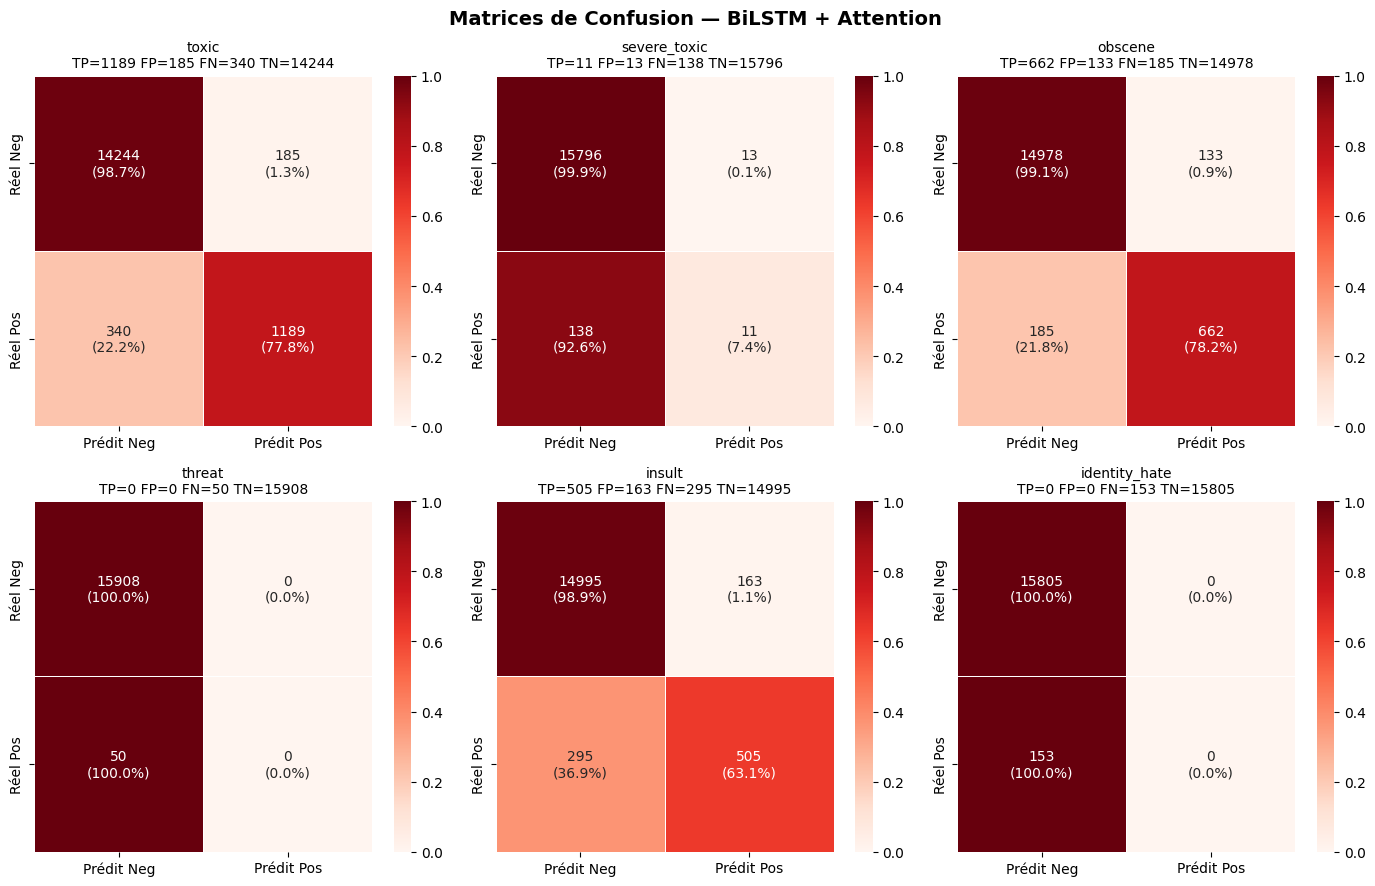

In [9]:
# Matrices de confusion
fig, axes = plt.subplots(2, 3, figsize=(14, 9))
axes = axes.flatten()

for idx, label in enumerate(LABELS):
    cm = confusion_matrix(y_val[:, idx], results_bilstm['y_pred'][:, idx])
    cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)
    annot = np.array([[f'{cm[i,j]}\n({cm_norm[i,j]*100:.1f}%)'
                       for j in range(2)] for i in range(2)])
    sns.heatmap(cm_norm, annot=annot, fmt='', cmap='Reds',
                ax=axes[idx], vmin=0, vmax=1, linewidths=0.5,
                xticklabels=['Prédit Neg', 'Prédit Pos'],
                yticklabels=['Réel Neg', 'Réel Pos'])
    tn, fp, fn, tp = cm.ravel()
    axes[idx].set_title(f'{label}\nTP={tp} FP={fp} FN={fn} TN={tn}', fontsize=10)

plt.suptitle('Matrices de Confusion — BiLSTM + Attention', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/toxic_comment_project/results/bilstm_confusion.png', dpi=150)
plt.show()

## 8. 💾 Sauvegarde

In [10]:
test_preds = model_bilstm.predict(X_test_pad, batch_size=512, verbose=1)
sub_df = pd.DataFrame(test_preds, columns=LABELS)
sub_df.insert(0, 'id', test_df['id'])
sub_df.to_csv('/content/drive/MyDrive/toxic_comment_project/results/submission_bilstm.csv', index=False)

pd.DataFrame([{
    'model': 'BiLSTM',
    'roc_auc_macro': results_bilstm['roc_auc_macro'],
    'f1_macro':      results_bilstm['f1_macro'],
    'f1_micro':      results_bilstm['f1_micro'],
    'f1_weighted':   results_bilstm['f1_weighted'],
    'train_time_min': round(train_time_bilstm / 60, 2),
    'n_params':       model_bilstm.count_params()
}]).to_csv('/content/drive/MyDrive/toxic_comment_project/results/metrics_bilstm.csv', index=False)

print('✅ Fichiers sauvegardés :')
print('   best_bilstm.keras | bilstm_history.png | bilstm_confusion.png')
print('   submission_bilstm.csv | metrics_bilstm.csv')
print(f'\n📊 ROC-AUC final : {results_bilstm["roc_auc_macro"]:.4f}')

300/300 ━━━━━━━━━━━━━━━━━━━━ 140s 465ms/step
✅ Fichiers sauvegardés :
   best_bilstm.keras | bilstm_history.png | bilstm_confusion.png
   submission_bilstm.csv | metrics_bilstm.csv

📊 ROC-AUC final : 0.9771
